<a href="https://colab.research.google.com/github/nguyendangcole/assignment-P4AI/blob/main/btl_ltAi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# connect kaggle

In [ ]:
!pip install -q kaggle

# declare token
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_a08f9b6b9025401467ead523f76d243c"

# down data
!kaggle datasets download -d faldoae/padangfood

!unzip -q padangfood.zip -d padang_dataset
print("finish")

Dataset URL: https://www.kaggle.com/datasets/faldoae/padangfood
License(s): ODbL-1.0
100% 114M/114M [00:01<00:00, 79.0MB/s]

finish


#Load & Inspect Data

In [ ]:
import pandas as pd
from pathlib import Path

# declare data path
data_dir = 'padang_dataset/dataset_padang_food'

# initilize list
paths = []
labels = []

print("scanning folder...")
for path in Path(data_dir).rglob('*.*'):
    if path.is_file():
        paths.append(str(path))         # save img path
        labels.append(path.parent.name)

# Create dataframe
df = pd.DataFrame({'path': paths, 'species': labels})

# sort table
df = df.sort_values('species').reset_index(drop=True)

# check
print("=========================================")
print(f"succesfull")
print(f"total img: {len(df)}")
print(f"Classes: {df['species'].nunique()}")
print("=========================================")
print("\ncheck first 5 row:")
display(df.head())

scanning folder...
succesfull
total img: 993
Classes: 9

check first 5 row:


,path,species
0,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
1,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
2,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
3,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng
4,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng


# Feature Extraction

In [ ]:
import cv2
import numpy as np
import os
from tqdm.notebook import tqdm

# Initialize lists to store parameters
widths, heights, aspect_ratios, file_sizes = [], [], [], []
mean_r, mean_g, mean_b = [], [], []
brightness, contrast, sharpness = [], [], []

print("starting scan img...")

# loop img in dataframe
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    img_path = row['path']

    # check file size
    file_sizes.append(os.path.getsize(img_path) / 1024.0)

    img = cv2.imread(img_path)

    if img is not None:
        # Size
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h if h != 0 else 0)

        # Color
        # OpenCV read img using the BGR color system, then -> RGB.
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_r.append(img_rgb[:, :, 0].mean())
        mean_g.append(img_rgb[:, :, 1].mean())
        mean_b.append(img_rgb[:, :, 2].mean())

        # Quality Metrics
        # Convert img to black, white -> brightness, contrast, and sharpness
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(gray.mean())               # Mean
        contrast.append(gray.std())                  # Standard deviation
        sharpness.append(cv2.Laplacian(gray, cv2.CV_64F).var()) # sharp
    else:
        # if error -> none
        widths.append(None); heights.append(None); aspect_ratios.append(None)
        mean_r.append(None); mean_g.append(None); mean_b.append(None)
        brightness.append(None); contrast.append(None); sharpness.append(None)

# push paramto to dataframe
df['width'] = widths
df['height'] = heights
df['aspect_ratio'] = aspect_ratios
df['file_size_kb'] = file_sizes
df['mean_r'] = mean_r
df['mean_g'] = mean_g
df['mean_b'] = mean_b
df['brightness'] = brightness
df['contrast'] = contrast
df['sharpness'] = sharpness

# delete img error
df = df.dropna().reset_index(drop=True)

print("\nFinish")
print("Display:")
display(df.head())

starting scan img...


  0%|          | 0/993 [00:00<?, ?it/s]


Finish
Display:


,path,species,width,height,aspect_ratio,file_size_kb,mean_r,mean_g,mean_b,brightness,contrast,sharpness
0,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,640,480,1.333333,191.596680,136.150495,101.063024,82.237656,109.421266,59.770518,2995.577492
1,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,699,507,1.378698,128.020508,137.795862,111.202081,84.467258,116.114932,72.020178,2242.834990
2,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,671,280,2.396429,66.001953,165.788104,102.962694,64.709229,117.403976,46.755443,651.260196
3,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,744,476,1.563025,182.117188,118.482485,96.212162,77.053419,100.691380,45.546991,187.067602
4,padang_dataset/dataset_padang_food/ayam_goreng...,ayam_goreng,496,149,3.328859,20.224609,153.028902,73.321106,25.181127,91.656771,45.492964,879.281764


#Visualizations

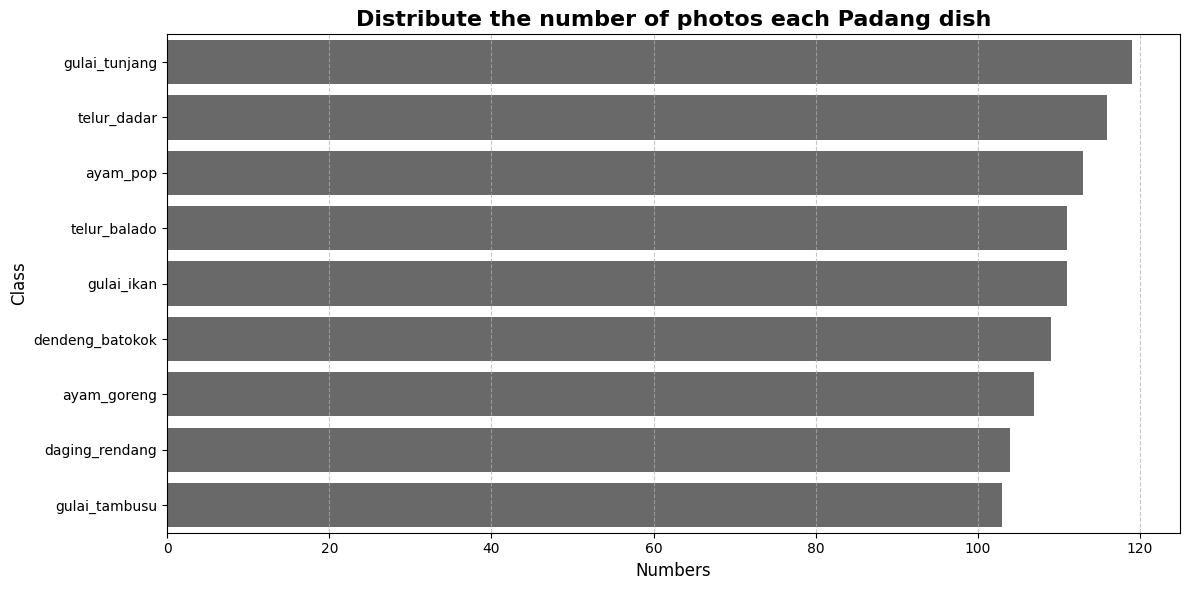

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='species', order=df['species'].value_counts().index, color='dimgray')

plt.title('Distribute the number of photos each Padang dish', fontsize=16, fontweight='bold')
plt.xlabel('Numbers', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import cv2

# list class
classes = sorted(df['species'].unique().tolist())

# scrool menu
dropdown = widgets.Dropdown(
    options=classes,
    value=classes[0],
    description='choose:',
    style={'description_width': 'initial'}
)
output = widgets.Output()

# change img when choose another class
def update_gallery(change):
    with output:
        clear_output(wait=True)
        selected_class = change.new

        # select random img in class
        class_df = df[df['species'] == selected_class]
        sample_imgs = class_df.sample(min(4, len(class_df))).reset_index(drop=True)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f"img: {selected_class.upper().replace('_', ' ')}", fontsize=16, fontweight='bold', y=1.05)

        for i in range(4):
            if i < len(sample_imgs):
                # Read, display img
                img = cv2.imread(sample_imgs.loc[i, 'path'])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
                axes[i].axis('off')
                axes[i].set_title(f"Size: {img.shape[1]}x{img.shape[0]}")
            else:
                axes[i].axis('off')

        plt.tight_layout()
        plt.show()

dropdown.observe(update_gallery, names='value')
display(dropdown, output)
dropdown.value = classes[1]
dropdown.value = classes[0]

Dropdown(description='choose:', options=('ayam_goreng', 'ayam_pop', 'daging_rendang', 'dendeng_batokok', 'gula…

Output()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

print("="*70)
print("📊 FINAL CORE EDA - Padang Cuisine Image Dataset (Plotly)")
print("="*70)

# Automatically generate a color palette for the 9 Padang cuisine classes
species_list = df['species'].unique()
palette = px.colors.qualitative.Prism
colors = {species: palette[i % len(palette)] for i, species in enumerate(species_list)}

# Common legend layout to avoid overlapping with titles
legend_layout = dict(
    orientation="h",
    yanchor="top",
    y=-0.2,
    xanchor="center",
    x=0.5
)
common_margin = dict(t=60, b=80, l=50, r=50)


# 1: Image Quality Metrics (Sharpness vs Contrast)

print("\n1️⃣ Creating Image Quality Metrics chart...")
fig1 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig1.add_trace(go.Scatter(
        x=species_data['sharpness'],
        y=species_data['contrast'],
        mode='markers',
        name=species.replace('_', ' ').title(),
        marker=dict(color=colors[species], size=7, opacity=0.7, line=dict(width=0.5, color='white')),
        text=species_data['path'].apply(lambda x: x.split('/')[-1]), # Extract filename for hover
        hovertemplate='<b>%{text}</b><br>Sharpness: %{x:.1f}<br>Contrast: %{y:.1f}<extra></extra>'
    ))

fig1.update_layout(
    title="Image Quality Metrics (Sharpness vs Contrast)",
    xaxis=dict(title="Sharpness (Laplacian Variance)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Contrast (Standard Deviation)", showgrid=True, gridcolor="#f0f0f0"),
    width=900, height=550, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig1.show()


# 2: RGB Color Space Distribution (3D Cube)
print("\n2️⃣ Creating 3D RGB Color Space chart...")
fig2 = go.Figure(data=[go.Scatter3d(
    x=df['mean_r'],
    y=df['mean_g'],
    z=df['mean_b'],
    mode='markers',
    marker=dict(
        size=4,
        color=df['brightness'],  # Color based on brightness
        colorscale='Viridis',
        opacity=0.7,
        colorbar=dict(title="Brightness", thickness=15, len=0.7, x=1.05)
    ),
    text=df['species'] + '<br>' + df['path'].apply(lambda x: x.split('/')[-1]),
    hovertemplate='<b>%{text}</b><br>Red: %{x:.1f}<br>Green: %{y:.1f}<br>Blue: %{z:.1f}<br>Brightness: %{marker.color:.1f}<extra></extra>'
)])

fig2.update_layout(
    title="RGB Color Space Distribution (3D Cube)",
    scene=dict(
        xaxis=dict(title='Red Channel', range=[0, 255]),
        yaxis=dict(title='Green Channel', range=[0, 255]),
        zaxis=dict(title='Blue Channel', range=[0, 255]),
        bgcolor='rgba(250, 250, 250, 0.9)'
    ),
    width=900, height=600, showlegend=False,
    margin=dict(t=60, b=20, l=20, r=20)
)
fig2.show()

# 3: Size Marginal Distribution (Width vs Height)
print("\nCreating Size Marginal Distribution chart...")
fig3 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig3.add_trace(go.Scatter(
        x=species_data['width'],
        y=species_data['height'],
        mode='markers',
        name=species.replace('_', ' ').title(),
        marker=dict(color=colors[species], size=6, opacity=0.7, line=dict(width=0.5, color='white')),
        text=species_data['path'].apply(lambda x: x.split('/')[-1]),
        hovertemplate='<b>%{text}</b><br>Width: %{x} px<br>Height: %{y} px<extra></extra>'
    ))

fig3.update_layout(
    title="Size Marginal Distribution (Width x Height)",
    xaxis=dict(title="Width (pixels)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Height (pixels)", showgrid=True, gridcolor="#f0f0f0"),
    width=900, height=550, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig3.show()

# 4: File Size Distribution
print("\nCreating File Size Distribution chart...")
fig4 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig4.add_trace(go.Histogram(
        x=species_data['file_size_kb'],
        name=species.replace('_', ' ').title(),
        opacity=0.7,
        marker_color=colors[species],
        nbinsx=40
    ))

fig4.update_layout(
    title="File Size Distribution",
    xaxis=dict(title="File Size (KB)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Count", showgrid=True, gridcolor="#f0f0f0"),
    barmode="overlay", # Overlapping histograms for comparison
    width=900, height=500, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig4.show()

# 5: Aspect Ratio Distribution
print("\nCreating Aspect Ratio Distribution chart...")
fig5 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig5.add_trace(go.Histogram(
        x=species_data['aspect_ratio'],
        name=species.replace('_', ' ').title(),
        opacity=0.7,
        marker_color=colors[species],
        nbinsx=40
    ))

# Add vertical lines for common aspect ratios
common_ratios = [0.75, 1.0, 1.33, 1.5, 1.77]
ratio_names = ['3:4 (Tall)', '1:1 (Square)', '4:3 (Wide)', '3:2', '16:9']
shapes = []
annotations = []

for ratio, name in zip(common_ratios, ratio_names):
    shapes.append(dict(type="line", x0=ratio, y0=0, x1=ratio, y1=1, yref="paper", line=dict(color="red", width=1.5, dash="dash")))
    annotations.append(dict(x=ratio, y=1, yref="paper", text=name, showarrow=False, yanchor="bottom", font=dict(size=10, color="red")))

fig5.update_layout(
    title="Aspect Ratio Distribution",
    xaxis=dict(title="Aspect Ratio (Width/Height)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Count", showgrid=True, gridcolor="#f0f0f0"),
    barmode="overlay",
    width=900, height=500, template="plotly_white",
    shapes=shapes, annotations=annotations,
    legend=legend_layout,
    margin=common_margin
)
fig5.show()

# ============================================================================
# STATISTICS SUMMARY
# ============================================================================
print("\n" + "="*70)
print("FINAL STATISTICS SUMMARY")
print("="*70)
print(f"Total Images: {len(df):,} images\n")

print(f"Dimensions:")
print(f"   • Mean width : {df['width'].mean():.1f} px (std: {df['width'].std():.1f})")
print(f"   • Mean height: {df['height'].mean():.1f} px (std: {df['height'].std():.1f})")
print(f"   • Min size   : {df['width'].min()} x {df['height'].min()} px")
print(f"   • Max size   : {df['width'].max()} x {df['height'].max()} px\n")

print(f"File Sizes:")
print(f"   • Mean   : {df['file_size_kb'].mean():.1f} KB")
print(f"   • Median : {df['file_size_kb'].median():.1f} KB")
print(f"   • Total  : {df['file_size_kb'].sum()/1024:.1f} MB\n")

print(f"Aspect Ratios:")
print(f"   • Mean   : {df['aspect_ratio'].mean():.2f}")
print(f"   • Median : {df['aspect_ratio'].median():.2f}")
print(f"   • Range  : {df['aspect_ratio'].min():.2f} - {df['aspect_ratio'].max():.2f}\n")

print(f"RGB Color Averages:")
print(f"   • Red   : {df['mean_r'].mean():.1f}")
print(f"   • Green : {df['mean_g'].mean():.1f}")
print(f"   • Blue  : {df['mean_b'].mean():.1f}")
print("="*70)
print("✅ EDA Complete! All required charts generated.")

📊 FINAL CORE EDA - Padang Cuisine Image Dataset (Plotly)

1️⃣ Creating Image Quality Metrics chart...



2️⃣ Creating 3D RGB Color Space chart...



Creating Size Marginal Distribution chart...



Creating File Size Distribution chart...



Creating Aspect Ratio Distribution chart...



FINAL STATISTICS SUMMARY
Total Images: 993 images

Dimensions:
   • Mean width : 730.1 px (std: 348.0)
   • Mean height: 518.4 px (std: 245.4)
   • Min size   : 72 x 72 px
   • Max size   : 2810 x 2188 px

File Sizes:
   • Mean   : 119.2 KB
   • Median : 68.2 KB
   • Total  : 115.6 MB

Aspect Ratios:
   • Mean   : 1.43
   • Median : 1.41
   • Range  : 0.56 - 3.33

RGB Color Averages:
   • Red   : 157.8
   • Green : 119.8
   • Blue  : 79.7
✅ EDA Complete! All required charts generated.


In [ ]:
import json

code1 = """import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

# Automatically generate a color palette for the 9 Padang cuisine classes
species_list = df['species'].unique()
palette = px.colors.qualitative.Prism
colors = {species: palette[i % len(palette)] for i, species in enumerate(species_list)}

# Common legend layout to avoid overlapping with titles
legend_layout = dict(
    orientation="h",
    yanchor="top",
    y=-0.2,
    xanchor="center",
    x=0.5
)
common_margin = dict(t=60, b=80, l=50, r=50)


# 1: Image Quality Metrics (Sharpness vs Contrast)

print("\n1️⃣ Creating Image Quality Metrics chart...")
fig1 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig1.add_trace(go.Scatter(
        x=species_data['sharpness'],
        y=species_data['contrast'],
        mode='markers',
        name=species.replace('_', ' ').title(),
        marker=dict(color=colors[species], size=7, opacity=0.7, line=dict(width=0.5, color='white')),
        text=species_data['path'].apply(lambda x: x.split('/')[-1]), # Extract filename for hover
        hovertemplate='<b>%{text}</b><br>Sharpness: %{x:.1f}<br>Contrast: %{y:.1f}<extra></extra>'
    ))

fig1.update_layout(
    title="Image Quality Metrics (Sharpness vs Contrast)",
    xaxis=dict(title="Sharpness (Laplacian Variance)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Contrast (Standard Deviation)", showgrid=True, gridcolor="#f0f0f0"),
    width=900, height=550, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig1.show()"""

code2 = """import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

# 2: RGB Color Space Distribution (3D Cube)
print("\n2️⃣ Creating 3D RGB Color Space chart...")
fig2 = go.Figure(data=[go.Scatter3d(
    x=df['mean_r'],
    y=df['mean_g'],
    z=df['mean_b'],
    mode='markers',
    marker=dict(
        size=4,
        color=df['brightness'],  # Color based on brightness
        colorscale='Viridis',
        opacity=0.7,
        colorbar=dict(title="Brightness", thickness=15, len=0.7, x=1.05)
    ),
    text=df['species'] + '<br>' + df['path'].apply(lambda x: x.split('/')[-1]),
    hovertemplate='<b>%{text}</b><br>Red: %{x:.1f}<br>Green: %{y:.1f}<br>Blue: %{z:.1f}<br>Brightness: %{marker.color:.1f}<extra></extra>'
)])

fig2.update_layout(
    title="RGB Color Space Distribution (3D Cube)",
    scene=dict(
        xaxis=dict(title='Red Channel', range=[0, 255]),
        yaxis=dict(title='Green Channel', range=[0, 255]),
        zaxis=dict(title='Blue Channel', range=[0, 255]),
        bgcolor='rgba(250, 250, 250, 0.9)'
    ),
    width=900, height=600, showlegend=False,
    margin=dict(t=60, b=20, l=20, r=20)
)
fig2.show()"""

code3 = """import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

# Automatically generate a color palette for the 9 Padang cuisine classes
species_list = df['species'].unique()
palette = px.colors.qualitative.Prism
colors = {species: palette[i % len(palette)] for i, species in enumerate(species_list)}

# Common legend layout to avoid overlapping with titles
legend_layout = dict(
    orientation="h",
    yanchor="top",
    y=-0.2,
    xanchor="center",
    x=0.5
)
common_margin = dict(t=60, b=80, l=50, r=50)

# 3: Size Marginal Distribution (Width vs Height)
print("\nCreating Size Marginal Distribution chart...")
fig3 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig3.add_trace(go.Scatter(
        x=species_data['width'],
        y=species_data['height'],
        mode='markers',
        name=species.replace('_', ' ').title(),
        marker=dict(color=colors[species], size=6, opacity=0.7, line=dict(width=0.5, color='white')),
        text=species_data['path'].apply(lambda x: x.split('/')[-1]),
        hovertemplate='<b>%{text}</b><br>Width: %{x} px<br>Height: %{y} px<extra></extra>'
    ))

fig3.update_layout(
    title="Size Marginal Distribution (Width x Height)",
    xaxis=dict(title="Width (pixels)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Height (pixels)", showgrid=True, gridcolor="#f0f0f0"),
    width=900, height=550, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig3.show()"""

code4 = """import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

# Automatically generate a color palette for the 9 Padang cuisine classes
species_list = df['species'].unique()
palette = px.colors.qualitative.Prism
colors = {species: palette[i % len(palette)] for i, species in enumerate(species_list)}

# Common legend layout to avoid overlapping with titles
legend_layout = dict(
    orientation="h",
    yanchor="top",
    y=-0.2,
    xanchor="center",
    x=0.5
)
common_margin = dict(t=60, b=80, l=50, r=50)

# 4: File Size Distribution
print("\nCreating File Size Distribution chart...")
fig4 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig4.add_trace(go.Histogram(
        x=species_data['file_size_kb'],
        name=species.replace('_', ' ').title(),
        opacity=0.7,
        marker_color=colors[species],
        nbinsx=40
    ))

fig4.update_layout(
    title="File Size Distribution",
    xaxis=dict(title="File Size (KB)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Count", showgrid=True, gridcolor="#f0f0f0"),
    barmode="overlay", # Overlapping histograms for comparison
    width=900, height=500, template="plotly_white",
    legend=legend_layout,
    margin=common_margin
)
fig4.show()"""

code5 = """import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

# Automatically generate a color palette for the 9 Padang cuisine classes
species_list = df['species'].unique()
palette = px.colors.qualitative.Prism
colors = {species: palette[i % len(palette)] for i, species in enumerate(species_list)}

# Common legend layout to avoid overlapping with titles
legend_layout = dict(
    orientation="h",
    yanchor="top",
    y=-0.2,
    xanchor="center",
    x=0.5
)
common_margin = dict(t=60, b=80, l=50, r=50)

# 5: Aspect Ratio Distribution
print("\nCreating Aspect Ratio Distribution chart...")
fig5 = go.Figure()

for species in species_list:
    species_data = df[df['species'] == species]
    fig5.add_trace(go.Histogram(
        x=species_data['aspect_ratio'],
        name=species.replace('_', ' ').title(),
        opacity=0.7,
        marker_color=colors[species],
        nbinsx=40
    ))

# Add vertical lines for common aspect ratios
common_ratios = [0.75, 1.0, 1.33, 1.5, 1.77]
ratio_names = ['3:4 (Tall)', '1:1 (Square)', '4:3 (Wide)', '3:2', '16:9']
shapes = []
annotations = []

for ratio, name in zip(common_ratios, ratio_names):
    shapes.append(dict(type="line", x0=ratio, y0=0, x1=ratio, y1=1, yref="paper", line=dict(color="red", width=1.5, dash="dash")))
    annotations.append(dict(x=ratio, y=1, yref="paper", text=name, showarrow=False, yanchor="bottom", font=dict(size=10, color="red")))

fig5.update_layout(
    title="Aspect Ratio Distribution",
    xaxis=dict(title="Aspect Ratio (Width/Height)", showgrid=True, gridcolor="#f0f0f0"),
    yaxis=dict(title="Count", showgrid=True, gridcolor="#f0f0f0"),
    barmode="overlay",
    width=900, height=500, template="plotly_white",
    shapes=shapes, annotations=annotations,
    legend=legend_layout,
    margin=common_margin
)
fig5.show()"""

# Create a single dictionary containing all your data
final_data = {
    "img_qualCode": code1,
    "img_qualChart": json.loads(fig1.to_json()), # Convert to dict so it nests correctly
    "rgb_spaceCode": code2,
    "rgb_spaceChart": json.loads(fig2.to_json()),
    "size_distCode": code3,
    "size_distChart": json.loads(fig3.to_json()),
    "file_sizeCode": code4,
    "file_sizeChart": json.loads(fig4.to_json()),
    "asp_ratioCode": code5,
    "asp_ratioChart": json.loads(fig5.to_json())
}

# Print the entire object as one valid JSON string
print(json.dumps(final_data, indent=2))

{
  "img_qualCode": "import plotly.graph_objects as go\nimport plotly.express as px\nimport pandas as pd\nimport numpy as np\n\n# Automatically generate a color palette for the 9 Padang cuisine classes\nspecies_list = df['species'].unique()\npalette = px.colors.qualitative.Prism\ncolors = {species: palette[i % len(palette)] for i, species in enumerate(species_list)}\n\n# Common legend layout to avoid overlapping with titles\nlegend_layout = dict(\n    orientation=\"h\",\n    yanchor=\"top\",\n    y=-0.2,\n    xanchor=\"center\",\n    x=0.5\n)\ncommon_margin = dict(t=60, b=80, l=50, r=50)\n\n\n# 1: Image Quality Metrics (Sharpness vs Contrast)\n\nprint(\"\n1\ufe0f\u20e3 Creating Image Quality Metrics chart...\")\nfig1 = go.Figure()\n\nfor species in species_list:\n    species_data = df[df['species'] == species]\n    fig1.add_trace(go.Scatter(\n        x=species_data['sharpness'],\n        y=species_data['contrast'],\n        mode='markers',\n        name=species.replace('_', ' ').title(